In [3]:
import numpy as np
import matplotlib.pyplot as pl
from five_vec import five_vec
import finufft

In [4]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

In [5]:
def t_max_calc(f0, beta, f_max):
    temp0 = 0.375/beta
    temp1 = 1-(f0/f_max)**(8/3)
    return temp0*temp1

def f_calc(f0, beta, t):
    return f0*(1-8/3*beta*t)**(-3/8)

In [6]:
def nufft(beta, data, t, bin_no):
    bins = np.arange(bin_no) - bin_no//2

    tau = -3/5*(1-8/3*beta*t)**(5/8)/beta
    scale = (2*pi)/(tau[-1]-tau[0])
    tau *= scale
    start_diff = -pi-tau[0]
    tau += start_diff
    nufft_amp = finufft.nufft1d1(
        tau.astype(np.float64), data.astype(complex), bin_no, eps=1e-12, upsampfac=2.0)/len(data)
    nufft_freq = -bins*scale/(2*pi)
    nufft_power = np.abs(nufft_amp)**2
    return nufft_freq, nufft_amp

In [ ]:
ephemeris = np.loadtxt("earth00-40-DE440.dat", delimiter = '\t', skiprows=18)
[t_eph, pos_x, pos_y, pos_z, vel_x, vel_y, vel_z, acc_x, acc_y, acc_z] = ephemeris.T

pos_arr = np.array([pos_x, pos_y, pos_z])
interp_pos = CubicSpline(t_eph, pos_arr.T)
v_arr = np.array([vel_x, vel_y, vel_z])
interp_v = CubicSpline(t_eph, v_arr.T)
acc_arr = np.array([acc_x, acc_y, acc_z])
interp_acc = CubicSpline(t_eph, acc_arr.T)

H_lat = 119.41 * np.pi/180 # rad
H_lng = 46.45 * np.pi/180 # rad

In [7]:
f0 = 30
Mc = 3e-2 * 2e30
f_max = 256
start_time = t_eph[abs(t_eph-(t_eph[0]+24*365*day)).argmin()] # very approximately 1st Jan 2024
side_day = 1e4/3 #86164.09053083288
n_days = 3
T_obs = n_days*side_day
beta = const*f0**(8/3)*Mc**(5/3)
f_signal = 3*f_max
nt = round(f_signal*T_obs)
t = (np.arange(nt)/f_signal).astype(np.longdouble)

f_source = f_calc(f0, beta, t)

phi = -6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta
freq_signal = 1*np.exp(1j*phi)

(29.997, 30.003)

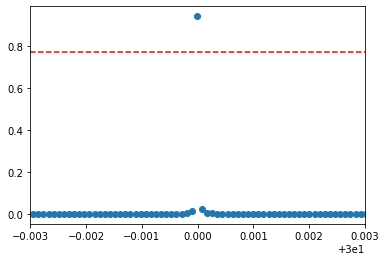

In [8]:
# Verify freq evolution is correct
nufft_freq, nufft_amp = nufft(beta, freq_signal, t, len(freq_signal))
pl.plot(nufft_freq, abs(nufft_amp)**2, 'o')
pl.axhline(2.4306/pi, c='r', ls='--')
pl.xlim(f0-0.003, f0+0.003)

In [9]:
f = f_calc(f0, beta, t)
d = 8e3*3.086e+16 # 8kpc
h0 = 4/d*(G*Mc/c**2)**(5/3)*(pi*f/c)**(2/3)

In [10]:
params = dict(ra = 0.5, dec = 0.5, eta = 0.5, psi = 0.5, lat = 0.5, 
              lng = 0.5, az = 0.5, side_day=side_day)
sidereal = five_vec(**params)
sidereal.compute_H()
sidereal.compute_A(t)
sidereal.compute_5vec()
amp_modulation = sidereal.amp_modulation

In [11]:
signal = h0*amp_modulation*freq_signal

fft_freqs, fft_amps = nufft(beta, signal, t, len(signal))
f0_idx = abs(fft_freqs-f0).argmin()

In [12]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

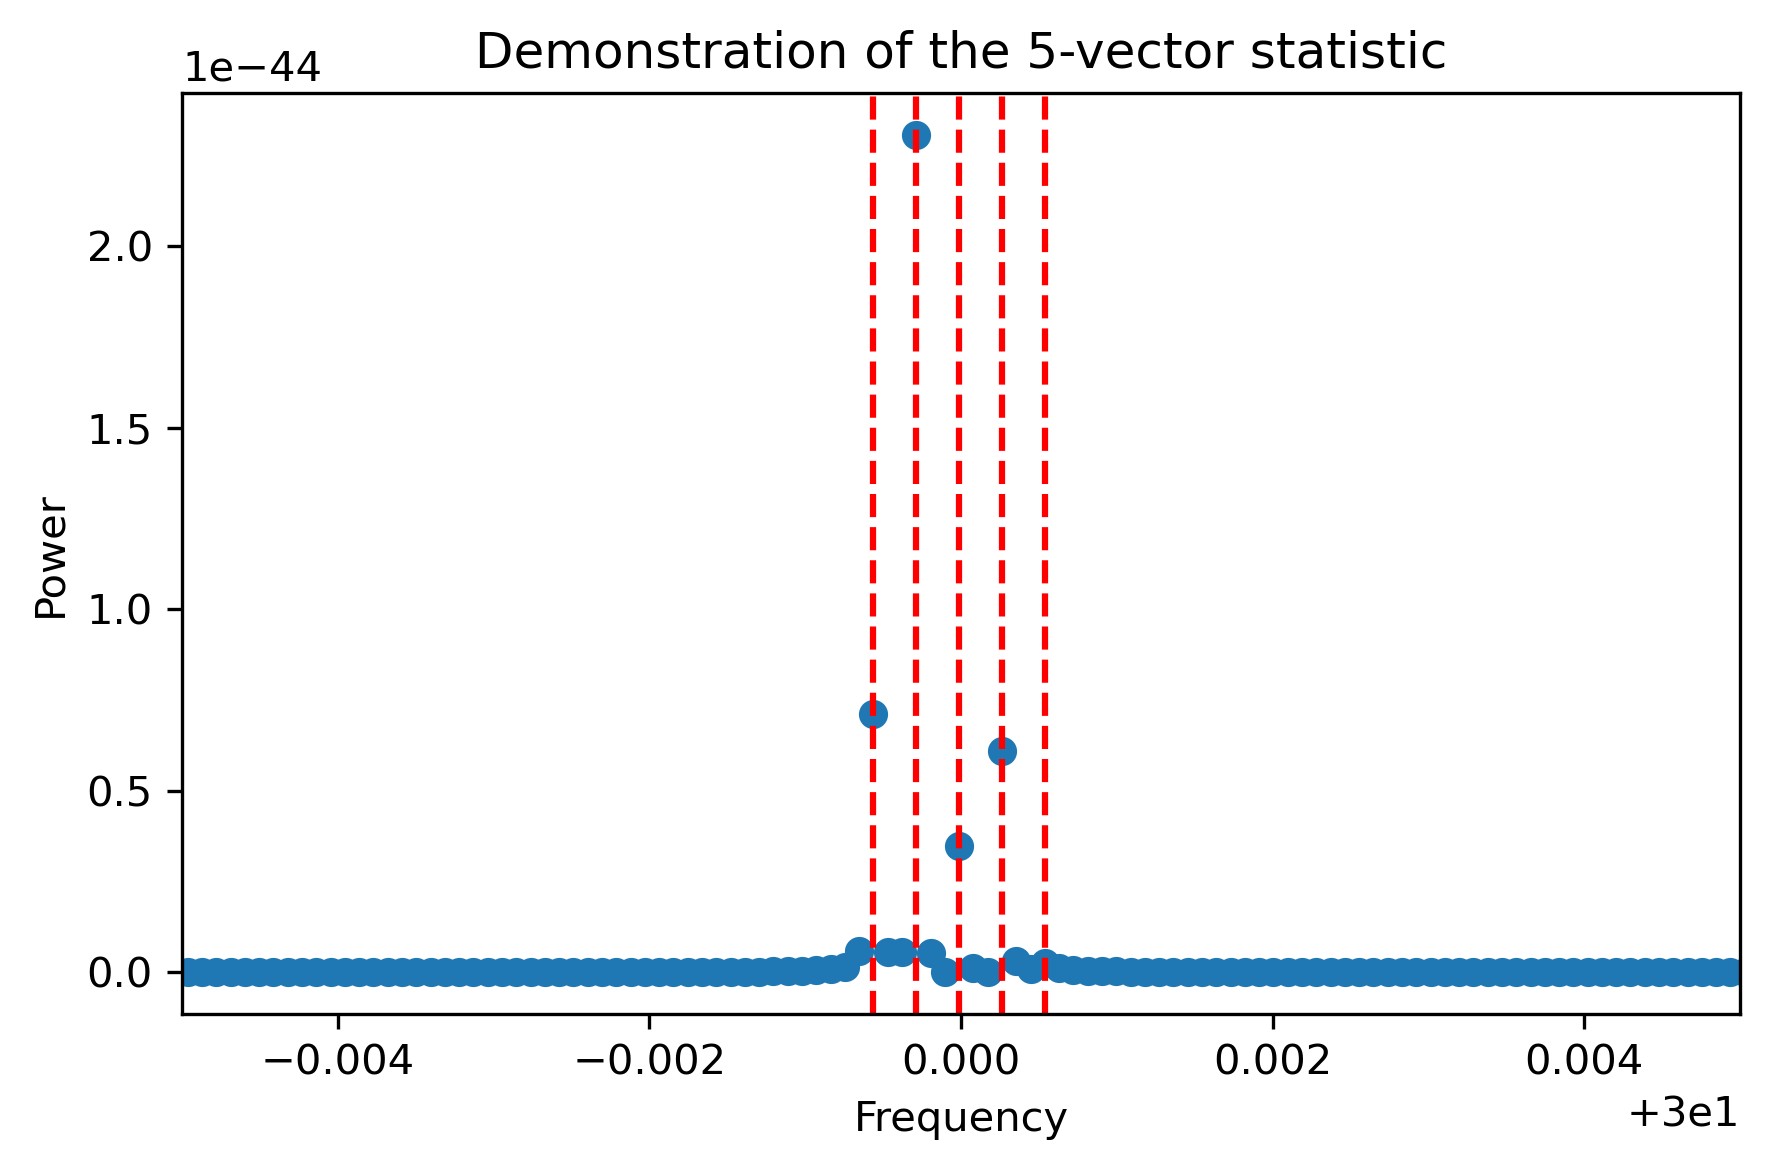

In [13]:
pl.plot(fft_freqs, abs(fft_amps)**2, 'o')
pl.xlim(f0-0.005, f0+0.005)
pl.axvline(fft_freqs[f0_idx-2*n_days], c='r', ls='--')
pl.axvline(fft_freqs[f0_idx-1*n_days], c='r', ls='--')
pl.axvline(fft_freqs[f0_idx], c='r', ls='--')
pl.axvline(fft_freqs[f0_idx+1*n_days], c='r', ls='--')
pl.axvline(fft_freqs[f0_idx+2*n_days], c='r', ls='--')
pl.xlabel("Frequency")
pl.ylabel("Power")
pl.title("Demonstration of the 5-vector statistic")
pl.tight_layout()

In [14]:
X = np.empty((5), dtype=complex)

f0_idx = abs(fft_freqs-f0).argmin()
X[0] = fft_amps[f0_idx-6]
X[1] = fft_amps[f0_idx-3]
X[2] = fft_amps[f0_idx]
X[3] = fft_amps[f0_idx+3]
X[4] = fft_amps[f0_idx+6]

In [15]:
estimator = abs(np.dot(X, np.conj(sidereal.A))/np.sum(np.abs(sidereal.A)**2))

Text(0, 0.5, 'h0')

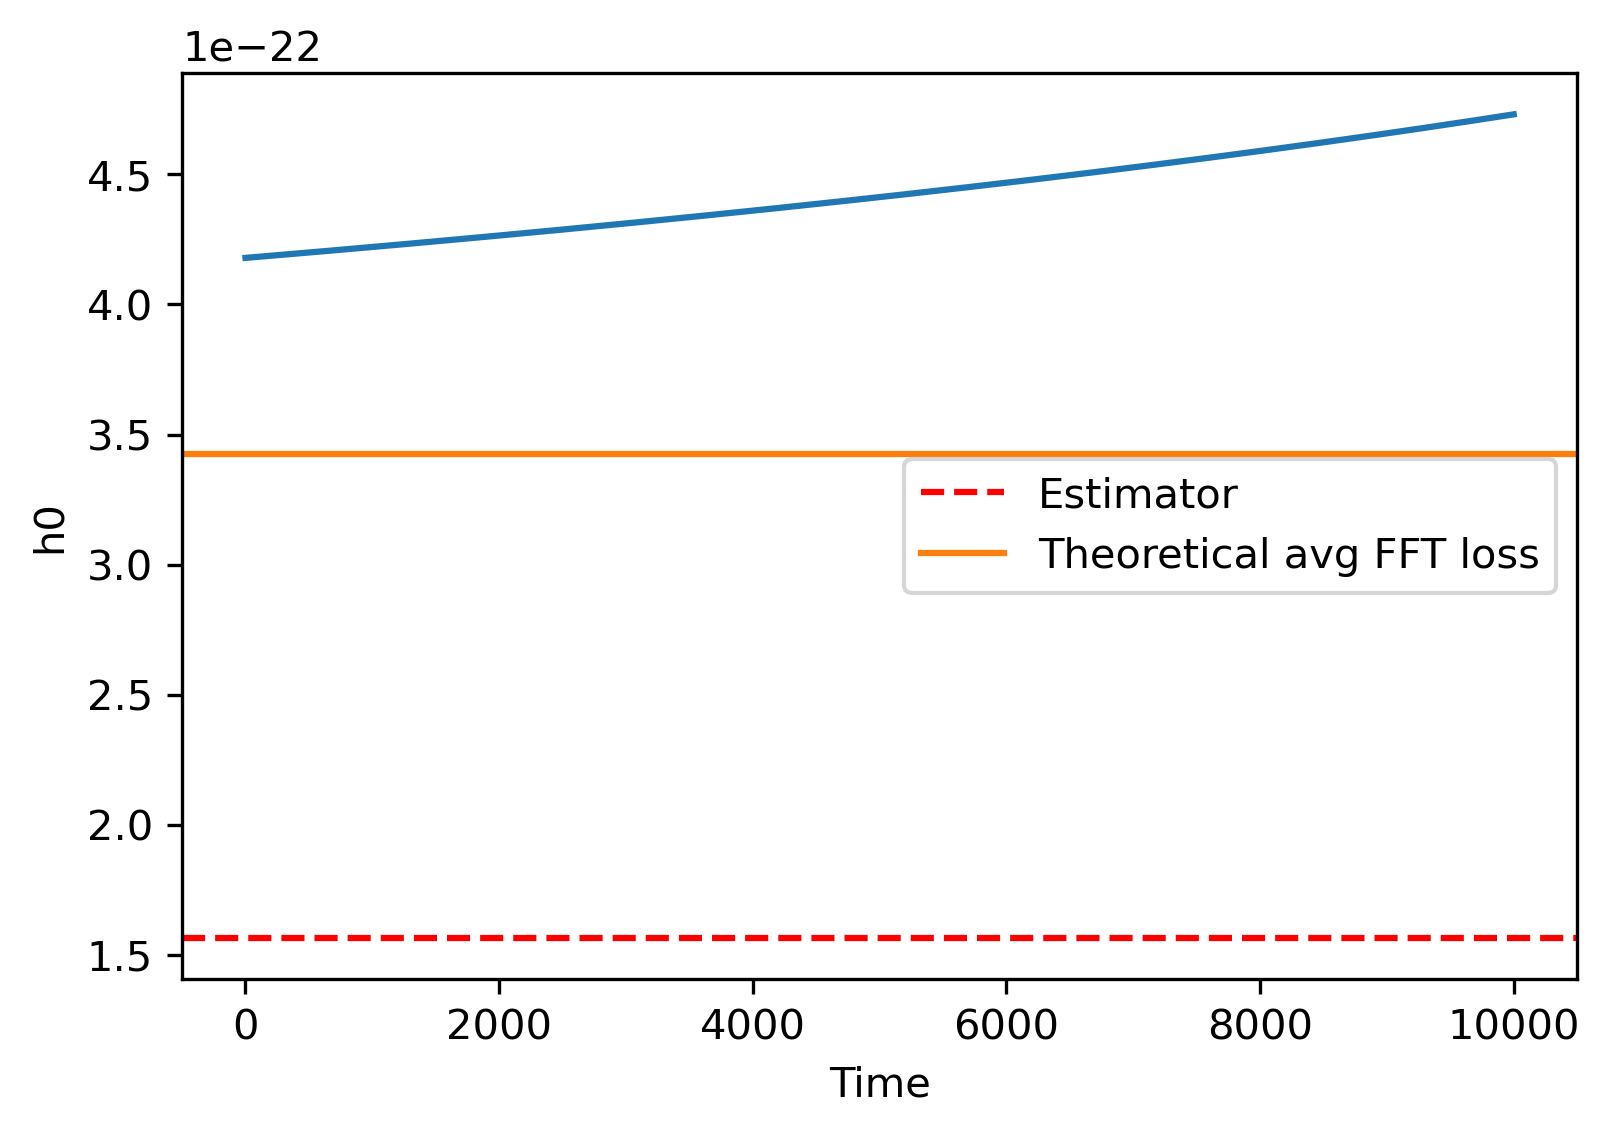

In [16]:
pl.plot(t[::100], h0[::100])
pl.axhline(estimator, c='r', ls='--', label = 'Estimator')
pl.axhline(2.4306/pi*np.average(h0), c='tab:orange', label="Theoretical avg FFT loss")
pl.legend()
pl.xlabel("Time")
pl.ylabel("h0")

In [17]:
2.4306/pi

0.7736840093583217